# Phân tích lỗi dự đoán và độ nhạy của TGAT

Notebook này tiếp nối kết quả GNNExplainer bằng hai kiểm tra bổ sung: phân tích trực tiếp FP/FN và control đã ghép, cùng ablation đầu vào của frozen TGAT.

Mọi can thiệp chỉ đo độ nhạy của model trên dữ liệu quan sát. `prediction_push > 0` nghĩa là đầu vào đang hỗ trợ phía dự đoán hiện tại của model; nó không chứng minh quan hệ nhân quả với fraud hay với lỗi ngoài thực tế.

In [1]:
from pathlib import Path
import json
import os
import sys

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root')

ROOT = find_project_root(Path.cwd())
SCRIPT_DIR = ROOT / 'scripts'
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import sprint5_2_prepare_error_cohorts as preparation
import sprint5_2_error_attribution as attribution_runner
import sprint5_2_tgat_ablation as ablation_runner

RUN_PREPARATION = os.getenv('RUN_SPRINT5_2_PREPARATION', '0') == '1'
RUN_ERROR_ATTRIBUTION = os.getenv('RUN_ERROR_ATTRIBUTION', '0') == '1'
RUN_TGAT_ABLATION = os.getenv('RUN_TGAT_ABLATION', '0') == '1'

summary = preparation.run(force_relock=False) if RUN_PREPARATION else json.loads(
    preparation.SUMMARY_PATH.read_text(encoding='utf-8')
)
attribution = attribution_runner.run() if RUN_ERROR_ATTRIBUTION else json.loads(
    attribution_runner.RESULT_PATH.read_text(encoding='utf-8')
)
ablation = ablation_runner.run() if RUN_TGAT_ABLATION else json.loads(
    ablation_runner.RESULT_PATH.read_text(encoding='utf-8')
)

import numpy as np
import pandas as pd
from IPython.display import Image, display

lock = json.loads(preparation.LOCK_PATH.read_text(encoding='utf-8'))
predictions = pd.read_csv(preparation.PREDICTION_PATH)
targets = pd.read_csv(preparation.TARGET_PATH)
threshold_curve = pd.read_csv(preparation.CURVE_PATH)

print(f'Project root: {ROOT}')
print(f'Preparation status: {summary["status"]}')
print(f'Prediction rows: {len(predictions):,} | selected targets: {len(targets):,}')

Project root: C:\Users\manhpnt\Documents\dgraph-fraud-ring-detection
Preparation status: preparation_complete
Prediction rows: 367,702 | selected targets: 160


## 1. Thiết lập và khóa protocol

Validation được dự đoán trước để chọn threshold. Protocol lưu hash dữ liệu/checkpoint, quy tắc chọn target, cùng các can thiệp dự kiến trước khi test được dự đoán. Khi file lock đã tồn tại, chạy lại notebook chỉ chấp nhận payload giống hệt; nó không âm thầm đổi threshold hoặc quy tắc chọn mẫu.

In [2]:
payload = lock['lock_payload']
protocol_table = pd.DataFrame([
    {'Thuộc tính': 'Dataset SHA-256', 'Giá trị': payload['data']['sha256']},
    {'Thuộc tính': 'Checkpoint SHA-256', 'Giá trị': payload['model']['checkpoint_sha256']},
    {'Thuộc tính': 'Model', 'Giá trị': f"variant {payload['model']['variant']}, seed {payload['model']['seed']}"},
    {'Thuộc tính': 'Graph', 'Giá trị': payload['model']['graph']},
    {'Thuộc tính': 'Neighborhood', 'Giá trị': str(payload['prediction_protocol']['num_neighbors'])},
    {'Thuộc tính': 'Threshold source', 'Giá trị': payload['threshold_selection']['source_split']},
    {'Thuộc tính': 'Test interpretation', 'Giá trị': payload['test_policy']['interpretation']},
])
display(protocol_table)
assert lock['status'] == 'locked_before_test_predictions'
assert payload['threshold_selection']['source_split'] == 'validation'
assert payload['test_policy']['test_not_used_to_change_threshold_targets_or_protocol']

,Thuộc tính,Giá trị
0,Dataset SHA-256,95470dab2c48523f7118a92204c090de37a957bb053bd5...
1,Checkpoint SHA-256,558db58e8c788edb8f5862b64093ef5a1a463debadd80e...
2,Model,"variant C, seed 42"
3,Graph,temporal_event_mirror
4,Neighborhood,[15]
5,Threshold source,validation
6,Test interpretation,"replication check, not a new blind holdout"


## 2. Khóa threshold trên validation

Do chưa có chi phí nghiệp vụ cụ thể cho FP và FN, threshold nghiên cứu được chọn bằng cách tối đa F1 của lớp fraud trên **toàn bộ validation**. Mọi fraud score duy nhất là một candidate threshold; nếu hòa F1 thì ưu tiên recall cao hơn, sau đó threshold thấp hơn. Test không tham gia phép chọn này.

,Threshold,Validation precision,Validation recall,Validation F1,Candidate thresholds,Final tie count
0,0.75738740,0.0510,0.2666,0.0857,182612,1


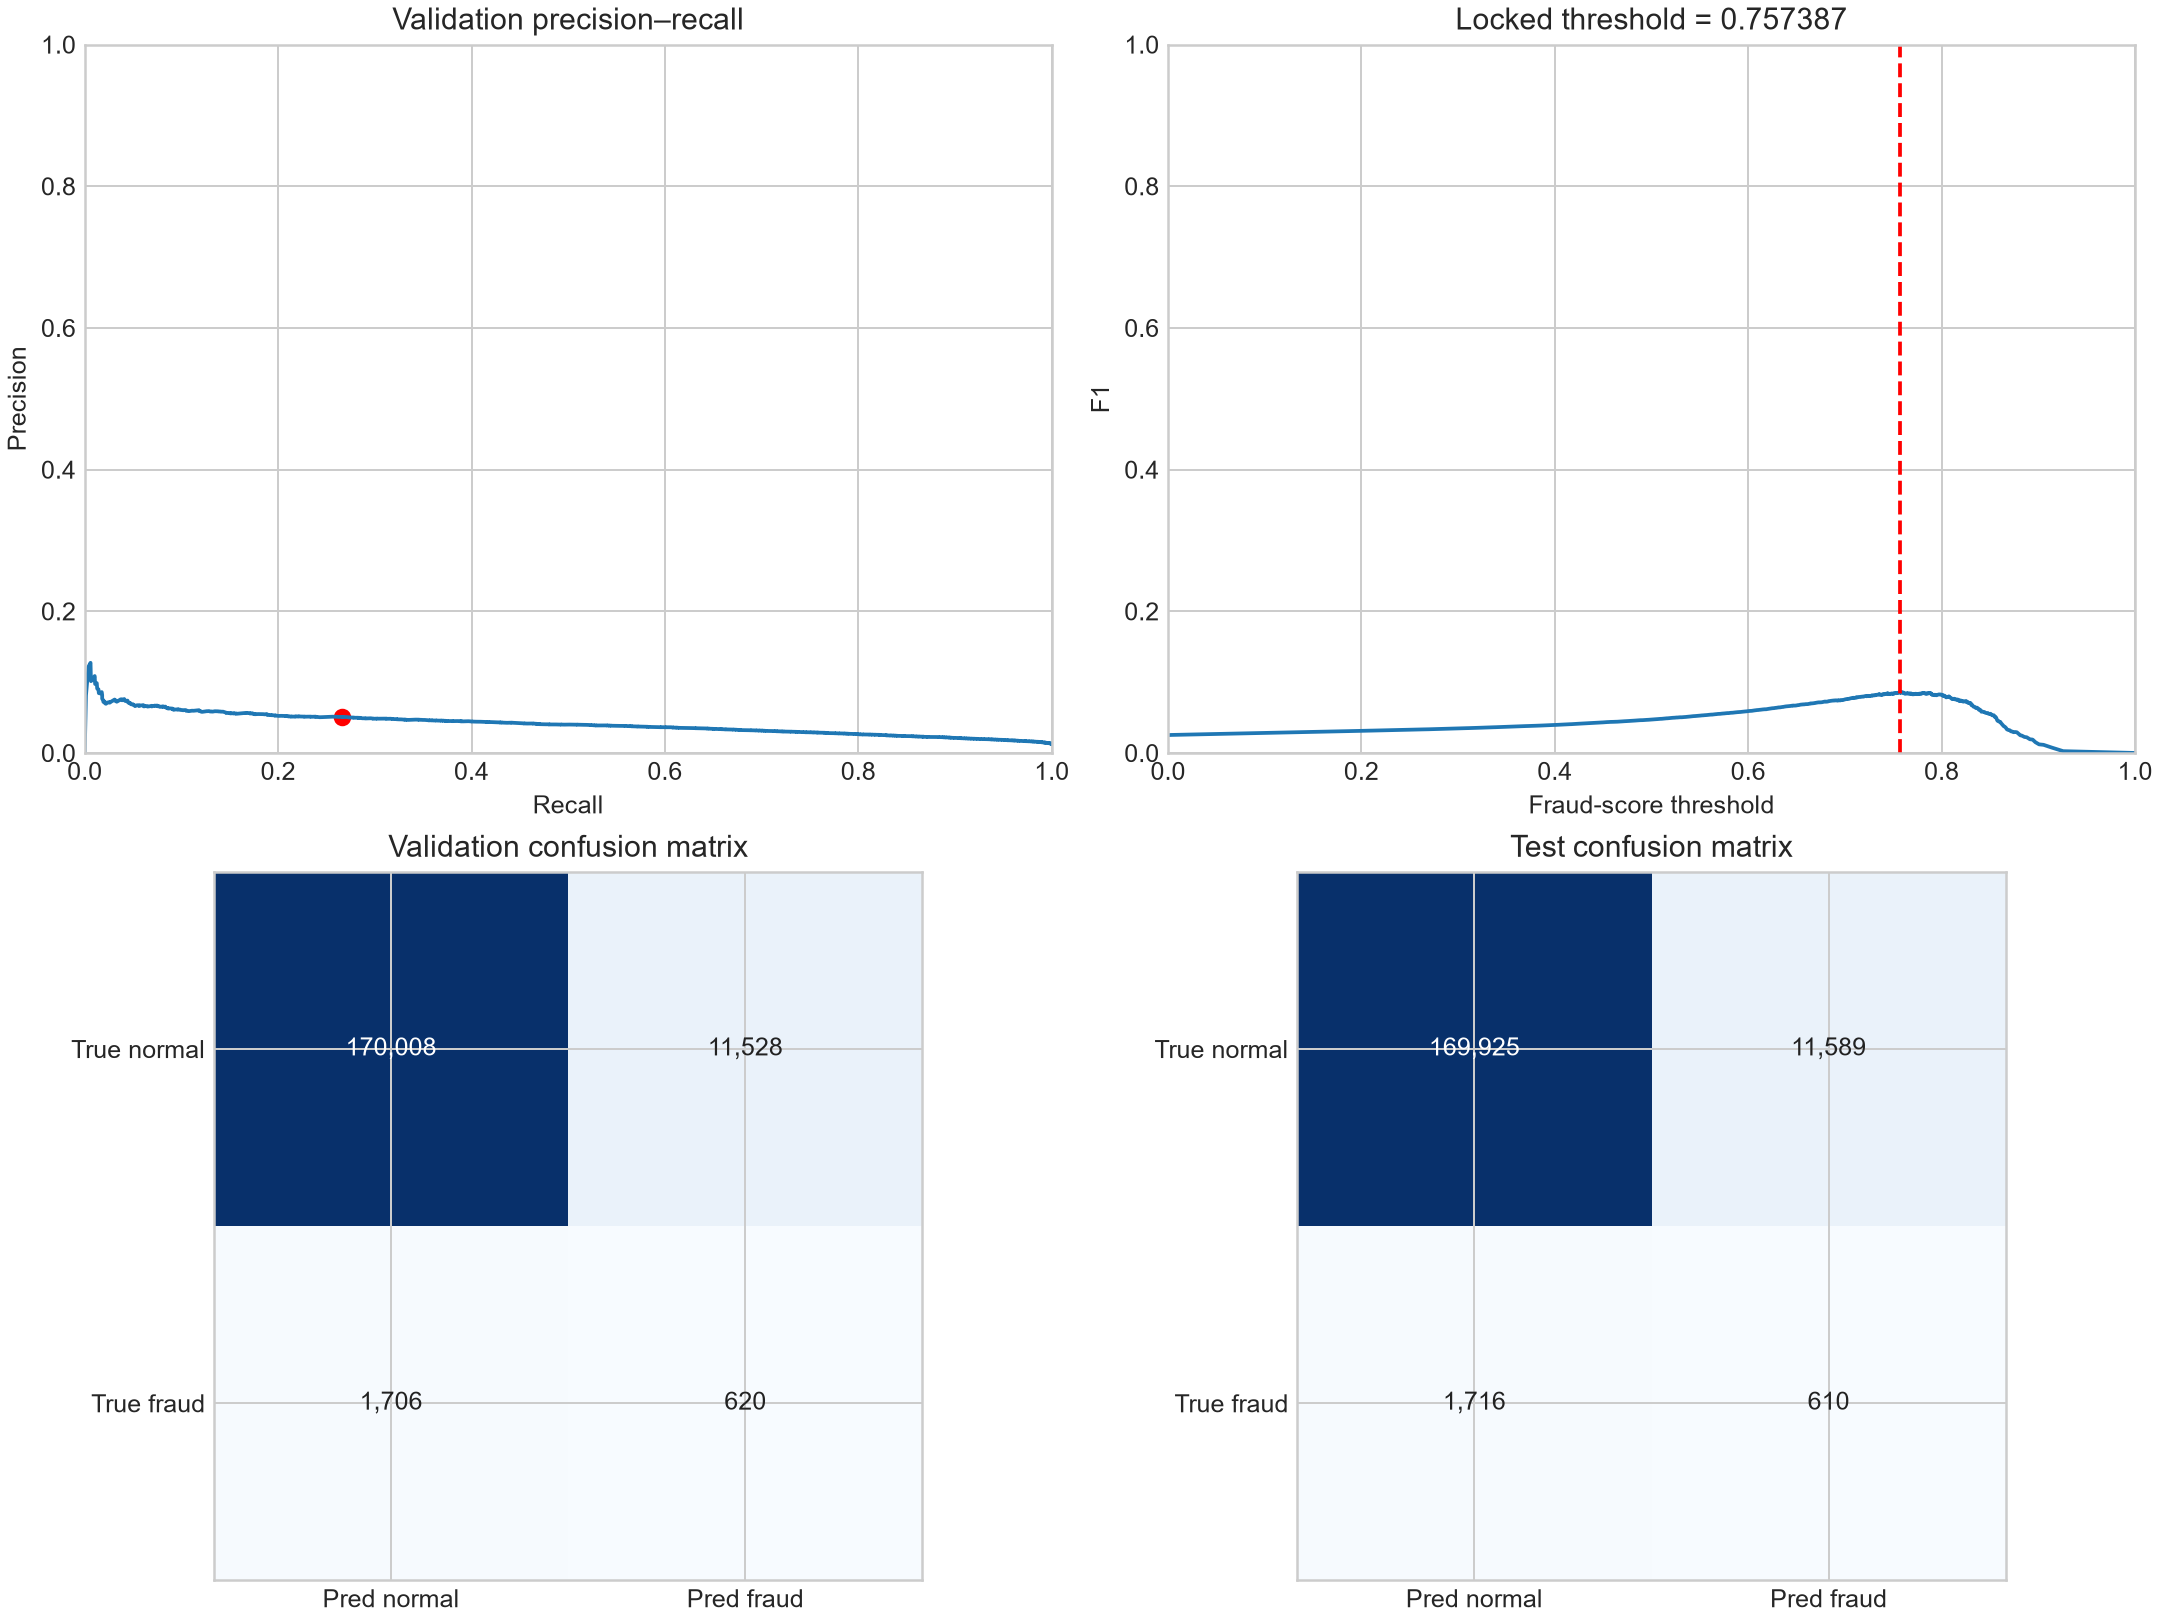

In [3]:
selected = summary['threshold']
selected_table = pd.DataFrame([{
    'Threshold': selected['threshold'],
    'Validation precision': selected['precision'],
    'Validation recall': selected['recall'],
    'Validation F1': selected['f1'],
    'Candidate thresholds': selected['candidate_count'],
    'Final tie count': selected['final_tie_count'],
}])
display(selected_table.style.format({
    'Threshold': '{:.8f}', 'Validation precision': '{:.4f}',
    'Validation recall': '{:.4f}', 'Validation F1': '{:.4f}',
}))

best_curve_f1 = float(threshold_curve['f1'].max())
assert np.isclose(selected['f1'], best_curve_f1, rtol=0, atol=1e-15)
assert np.isclose(
    selected['threshold'], payload['threshold_selection']['selected']['threshold'],
    rtol=0, atol=0
)
display(Image(filename=str(preparation.FIGURE_PATH), width=1050))

## 3. TP, FP, FN và TN tại threshold đã khóa

Cùng toán tử `fraud_score >= threshold` được áp dụng nguyên trạng cho validation và test. AP/ROC-AUC được giữ để xác nhận prediction tái lập checkpoint; precision, recall và F1 dưới đây mới phụ thuộc threshold.

In [4]:
metric_rows = []
for split in ('validation', 'test'):
    metrics = summary['split_metrics'][split]
    counts = metrics['confusion_matrix']
    metric_rows.append({
        'Split': split, 'N': metrics['sample_count'],
        'TP': counts['TP'], 'FP': counts['FP'], 'FN': counts['FN'], 'TN': counts['TN'],
        'Precision': metrics['precision'], 'Recall': metrics['recall'], 'F1': metrics['f1'],
        'AP': metrics['average_precision'], 'ROC-AUC': metrics['roc_auc'],
    })
metric_table = pd.DataFrame(metric_rows)
display(metric_table.style.format({
    'N': '{:,.0f}', 'TP': '{:,.0f}', 'FP': '{:,.0f}', 'FN': '{:,.0f}', 'TN': '{:,.0f}',
    'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}',
    'AP': '{:.4f}', 'ROC-AUC': '{:.4f}',
}))

observed_counts = predictions.groupby(['split', 'cohort']).size().unstack(fill_value=0)
display(observed_counts[['TP', 'FP', 'FN', 'TN']])
assert predictions.groupby('split')['node_id'].nunique().eq(predictions.groupby('split').size()).all()
assert set(predictions['cohort']) == {'TP', 'FP', 'FN', 'TN'}

,Split,N,TP,FP,FN,TN,Precision,Recall,F1,AP,ROC-AUC
0,validation,"183,862",620,"11,528","1,706","170,008",0.0510,0.2666,0.0857,0.0415,0.7817
1,test,"183,840",610,"11,589","1,716","169,925",0.0500,0.2623,0.0840,0.0445,0.7856


cohort,TP,FP,FN,TN
split,,,,
test,610,11589,1716,169925
validation,620,11528,1706,170008


## 4. Chọn lỗi và control để phân tích sâu

Mỗi split lấy tối đa 20 FP và 20 FN. Một nửa lỗi nằm gần threshold, phần còn lại là các lỗi tự tin nhất. FP được ghép với TP và FN được ghép với TN ở cùng phía dự đoán. Matching không hoàn lại, ưu tiên score bin, `log1p(degree)`, số sampled event, fraud score và cuối cùng node ID. Explainer mask hoặc perturbation result không tham gia chọn mẫu.

In [5]:
target_counts = (
    targets.groupby(['split', 'target_role', 'cohort'])
    .size().rename('N').reset_index()
)
display(target_counts)

matching_quality = (
    targets[targets['target_role'] == 'error']
    .groupby(['split', 'error_cohort'])[[
        'match_score_bin_delta', 'match_score_delta',
        'match_log1p_degree_delta', 'match_event_count_delta',
    ]]
    .agg(['median', 'max'])
)
display(matching_quality)
display(targets.head(8))

assert targets[['split', 'node_id']].duplicated().sum() == 0
assert targets.groupby(['split', 'pair_id']).size().eq(2).all()
assert targets.groupby(['split', 'pair_id'])['target_role'].nunique().eq(2).all()
assert set(targets.loc[targets.target_role == 'error', 'cohort']) == {'FP', 'FN'}

,split,target_role,cohort,N
0,test,control,TN,20
1,test,control,TP,20
2,test,error,FN,20
3,test,error,FP,20
4,validation,control,TN,20
5,validation,control,TP,20
6,validation,error,FN,20
7,validation,error,FP,20


match_score_bin_delta     match_score_delta            \
                                       median max            median       max   
split      error_cohort                                                         
test       FN                             0.0   0          0.000010  0.000032   
           FP                             0.0   0          0.014276  0.090028   
validation FN                             0.0   0          0.000014  0.000165   
           FP                             0.0   0          0.016317  0.080251   

                        match_log1p_degree_delta            \
                                          median       max   
split      error_cohort                                      
test       FN                                0.0  0.000000   
           FP                                0.0  0.847298   
validation FN                                0.0  0.000000   
           FP                                0.0  0.000000   

                        match_event_count_delta      
                                         median max  
split      error_cohort                              
test       FN                               0.0   0  
           FP                               0.0   4  
validation FN                               0.0   0  
           FP                               0.0   0

,split,pair_id,pair_order,error_cohort,target_role,cohort,selection_stratum,node_id,matched_node_id,label,...,distance_to_threshold,in_degree,log1p_degree,sampled_event_count,score_bin,batch_key,match_score_bin_delta,match_score_delta,match_log1p_degree_delta,match_event_count_delta
0,validation,validation_fp_00,0,FP,error,FP,near_threshold,2364597,2789155,0,...,0.000002,3,1.386294,3,7,validation_target_2364597,0,0.000004,0.0,0
1,validation,validation_fp_00,0,FP,control,TP,matched_near_threshold,2789155,2364597,1,...,0.000006,3,1.386294,3,7,validation_target_2789155,0,0.000004,0.0,0
2,validation,validation_fp_01,1,FP,error,FP,near_threshold,1092145,1194485,0,...,0.000006,1,0.693147,1,7,validation_target_1092145,0,0.000006,0.0,0
3,validation,validation_fp_01,1,FP,control,TP,matched_near_threshold,1194485,1092145,1,...,0.000000,1,0.693147,1,7,validation_target_1194485,0,0.000006,0.0,0
4,validation,validation_fp_02,2,FP,error,FP,near_threshold,1035592,134632,0,...,0.000007,1,0.693147,1,7,validation_target_1035592,0,0.000065,0.0,0
5,validation,validation_fp_02,2,FP,control,TP,matched_near_threshold,134632,1035592,1,...,0.000072,1,0.693147,1,7,validation_target_134632,0,0.000065,0.0,0
6,validation,validation_fp_03,3,FP,error,FP,near_threshold,482285,1743061,0,...,0.000011,2,1.098612,2,7,validation_target_482285,0,0.000497,0.0,0
7,validation,validation_fp_03,3,FP,control,TP,matched_near_threshold,1743061,482285,1,...,0.000508,2,1.098612,2,7,validation_target_1743061,0,0.000497,0.0,0


## 5. Frozen local batches

Mỗi target đã chọn có một local batch một hop, tối đa 15 event và neighborhood seed 42. Validation và test được lưu riêng để lock validation không bị sửa sau khi test được mở. Batch chứa node feature, local edge index, `edge_delta`, timestamp, edge type, global node/event ID và batch size.

In [6]:
batch_rows = []
for split, path in (
    ('validation', preparation.VALIDATION_BATCH_PATH),
    ('test', preparation.TEST_BATCH_PATH),
):
    with np.load(path, allow_pickle=False) as archive:
        keys = archive.files
        target_prefixes = {key.rsplit('_', 1)[0] for key in keys if key.endswith('_x')}
        x_shapes = [archive[key].shape for key in keys if key.endswith('_x')]
        edge_shapes = [archive[key].shape for key in keys if key.endswith('_edge_index')]
    batch_rows.append({
        'Split': split, 'Target batches': len(target_prefixes), 'Stored arrays': len(keys),
        'Feature widths': sorted({shape[1] for shape in x_shapes}),
        'Maximum events': max(shape[1] for shape in edge_shapes),
    })
display(pd.DataFrame(batch_rows))

batch_gates = {
    key: value for key, value in summary['gate_checks'].items()
    if 'batch' in key or 'adapter' in key or 'model_state' in key
}
display(pd.DataFrame(batch_gates.items(), columns=['Check', 'Passed']))
assert all(batch_gates.values())

,Split,Target batches,Stored arrays,Feature widths,Maximum events
0,validation,80,640,[35],8
1,test,80,640,[35],7


,Check,Passed
0,validation_adapter_equivalence,True
1,test_adapter_equivalence,True
2,validation_batch_event_counts_match,True
3,test_batch_event_counts_match,True
4,model_state_unchanged,True


## 6. Kiểm tra tái lập và gate

Prediction phải khớp AP/ROC-AUC của checkpoint trong sai số `1e-6`; adapter phải cho cùng logit với forward gốc trên frozen batch; model state phải giữ nguyên; cohort phải đầy đủ, không trùng node và mỗi pair phải có đúng một error cùng một control.

In [7]:
reproduction_rows = []
for split, values in summary['reproduction'].items():
    reproduction_rows.append({'Split': split, **values})
reproduction_table = pd.DataFrame(reproduction_rows)
numeric_columns = reproduction_table.select_dtypes(include='number').columns
display(reproduction_table.style.format({column: '{:.3e}' for column in numeric_columns}))

gate_table = pd.DataFrame(
    summary['gate_checks'].items(), columns=['Check', 'Passed']
)
display(gate_table)
failed = gate_table.loc[~gate_table['Passed']]
assert summary['gate_passed'], failed.to_dict('records')
assert failed.empty
print(f"All {len(gate_table)} checks passed. Protocol payload: {summary['protocol']['payload_sha256']}")

,Split,average_precision_absolute_difference,roc_auc_absolute_difference
0,validation,0.000e+00,2.220e-16
1,test,6.939e-18,2.220e-16


,Check,Passed
0,dataset_hash_matches_plan,True
1,checkpoint_hash_matches_plan,True
2,community_feature_hash_matches_plan,True
3,validation_ap_reproduced,True
4,validation_roc_auc_reproduced,True
5,test_ap_reproduced,True
6,test_roc_auc_reproduced,True
7,protocol_locked_before_test_predictions,True
8,threshold_uses_validation_only,True
9,validation_counts_match_checkpoint,True


All 22 checks passed. Protocol payload: fb0fb542eb695b23fbcc8bc3c059504863b753e1430e263188cb3aac733f321f


## 7. Dữ liệu phân tích đã khóa

Threshold validation là **0,75738740**. Tại ngưỡng này, validation có 620 TP, 11.528 FP, 1.706 FN và 170.008 TN; test có 610 TP, 11.589 FP, 1.716 FN và 169.925 TN. Precision thấp phản ánh class imbalance mạnh và cho thấy threshold tối đa F1 vẫn tạo nhiều cảnh báo nhầm.

Danh sách gồm 160 target: trên mỗi split có 20 FP, 20 FN và 40 control TP/TN đã ghép. Các frozen local batch, model hash và neighborhood seed không đổi trong các phân tích tiếp theo.

## 8. Feature nào thực sự gắn riêng với dự đoán sai?

Mỗi FP được ghép với một TP cùng phía dự đoán fraud; mỗi FN được ghép với một TN cùng phía dự đoán normal. Control được chọn gần error theo score, degree và số event.

Với từng node, mỗi feature được thay riêng bằng mức tham chiếu rồi model được chạy lại. Notebook tính `prediction_push(error) - prediction_push(control)` trong từng cặp. Một feature chỉ được đưa vào bảng khi push trung vị trên error dương và chênh lệch trung vị error–control cũng dương. Điều kiện thứ nhất cho biết feature hỗ trợ dự đoán sai; điều kiện thứ hai cho biết mức hỗ trợ đó mạnh hơn ở error so với control. Giá trị 0 chỉ là mốc so sánh, không phải thao tác xóa feature hay một trạng thái trung tính.


In [8]:
error_feature_rows = pd.DataFrame([
    row for row in attribution['target_summaries'] if row['cohort'] in {'FP', 'FN'}
])
pair_feature_rows = pd.DataFrame([
    {'split': group['split'], 'pair': group['error_cohort'] + '–' + group['control_cohort'], **feature}
    for group in attribution['error_control_summaries']
    for feature in group['feature_contrasts']
])
candidate_rows = []
for group in attribution['error_control_summaries']:
    pair = group['error_cohort'] + '–' + group['control_cohort']
    names = set(group['positive_error_specific_candidates'])
    if not names:
        candidate_rows.append({
            'split': group['split'],
            'pair': pair,
            'feature_name': 'Không có',
        })
        continue
    for feature in group['feature_contrasts']:
        if feature['feature_name'] in names:
            candidate_rows.append({
                'split': group['split'],
                'pair': pair,
                **feature,
            })

candidate_table = pd.DataFrame(candidate_rows)
display(candidate_table[[
    'split', 'pair', 'feature_name', 'error_median_prediction_push',
    'paired_median_prediction_push_difference', 'paired_difference_positive_rate',
]].style.format({
    'error_median_prediction_push': '{:.4f}',
    'paired_median_prediction_push_difference': '{:.4f}',
    'paired_difference_positive_rate': '{:.0%}',
}, na_rep='—'))

assert attribution['technical_gates']['all_160_locked_targets_processed']
assert attribution['technical_gates']['all_80_error_control_pairs_processed']
assert attribution['technical_gates']['all_pair_contrasts_finite']
assert attribution['technical_gates']['model_state_unchanged']
assert attribution['technical_gates']['all_feature_values_finite']


,split,pair,feature_name,error_median_prediction_push,paired_median_prediction_push_difference,paired_difference_positive_rate
0,validation,FP–TP,Không có,—,—,—
1,validation,FN–TN,Không có,—,—,—
2,test,FP–TP,F16-missing,0.0138,0.0008,50%
3,test,FN–TN,community-risk,0.0259,0.0201,55%


## 9. Community-risk trong FP và FN

Community-risk được tách riêng vì đây là feature train-only bổ sung sau message passing. Bảng dưới báo effect có dấu, IQR và tỷ lệ effect dương. Effect dương chỉ nói feature hỗ trợ phía dự đoán hiện tại trên phép thay giá trị tham chiếu này.


In [9]:
risk_table = error_feature_rows[[
    'split', 'cohort', 'community_risk_median_prediction_push',
    'community_risk_iqr_prediction_push', 'community_risk_positive_rate',
]].copy()
display(risk_table.style.format({
    'community_risk_median_prediction_push': '{:.4f}',
    'community_risk_positive_rate': '{:.1%}',
}))

print('Feature-mask nonzero-gradient rate:', attribution['diagnostics']['feature_nonzero_gradient_rate'])


,split,cohort,community_risk_median_prediction_push,community_risk_iqr_prediction_push,community_risk_positive_rate
0,validation,FP,0.0056,"[-0.05463394522666931, 0.046314507722854614]",55.0%
1,validation,FN,-0.0146,"[-0.07527044415473938, 0.07292520999908447]",40.0%
2,test,FP,0.0231,"[-0.012001663446426392, 0.05541956424713135]",65.0%
3,test,FN,0.0259,"[-0.10268822312355042, 0.08200621604919434]",70.0%


Feature-mask nonzero-gradient rate: 1.0


## 10. Độ nhạy của frozen TGAT

Bốn cấu hình chạy trên toàn bộ validation và test với cùng loader: FULL, thời gian hằng trong neighborhood, neighbor về baseline và tắt message passing. Bảng dùng AP và ROC-AUC để nhất quán với cách đánh giá model ở các sprint trước. Đây là ablation ở thời điểm inference, không phải retraining.


,split,variant,average_precision,delta_ap,roc_auc,delta_roc_auc
0,validation,FULL,0.0415,+0.0000,0.7817,+0.0000
1,validation,T-CONST,0.0392,-0.0023,0.7671,-0.0146
2,validation,N-BASE,0.0348,-0.0067,0.7624,-0.0192
3,validation,MP-OFF,0.0273,-0.0142,0.7224,-0.0592
4,test,FULL,0.0445,+0.0000,0.7856,+0.0000
5,test,T-CONST,0.0426,-0.0019,0.7736,-0.0120
6,test,N-BASE,0.0356,-0.0089,0.7625,-0.0230
7,test,MP-OFF,0.0286,-0.0160,0.7258,-0.0598


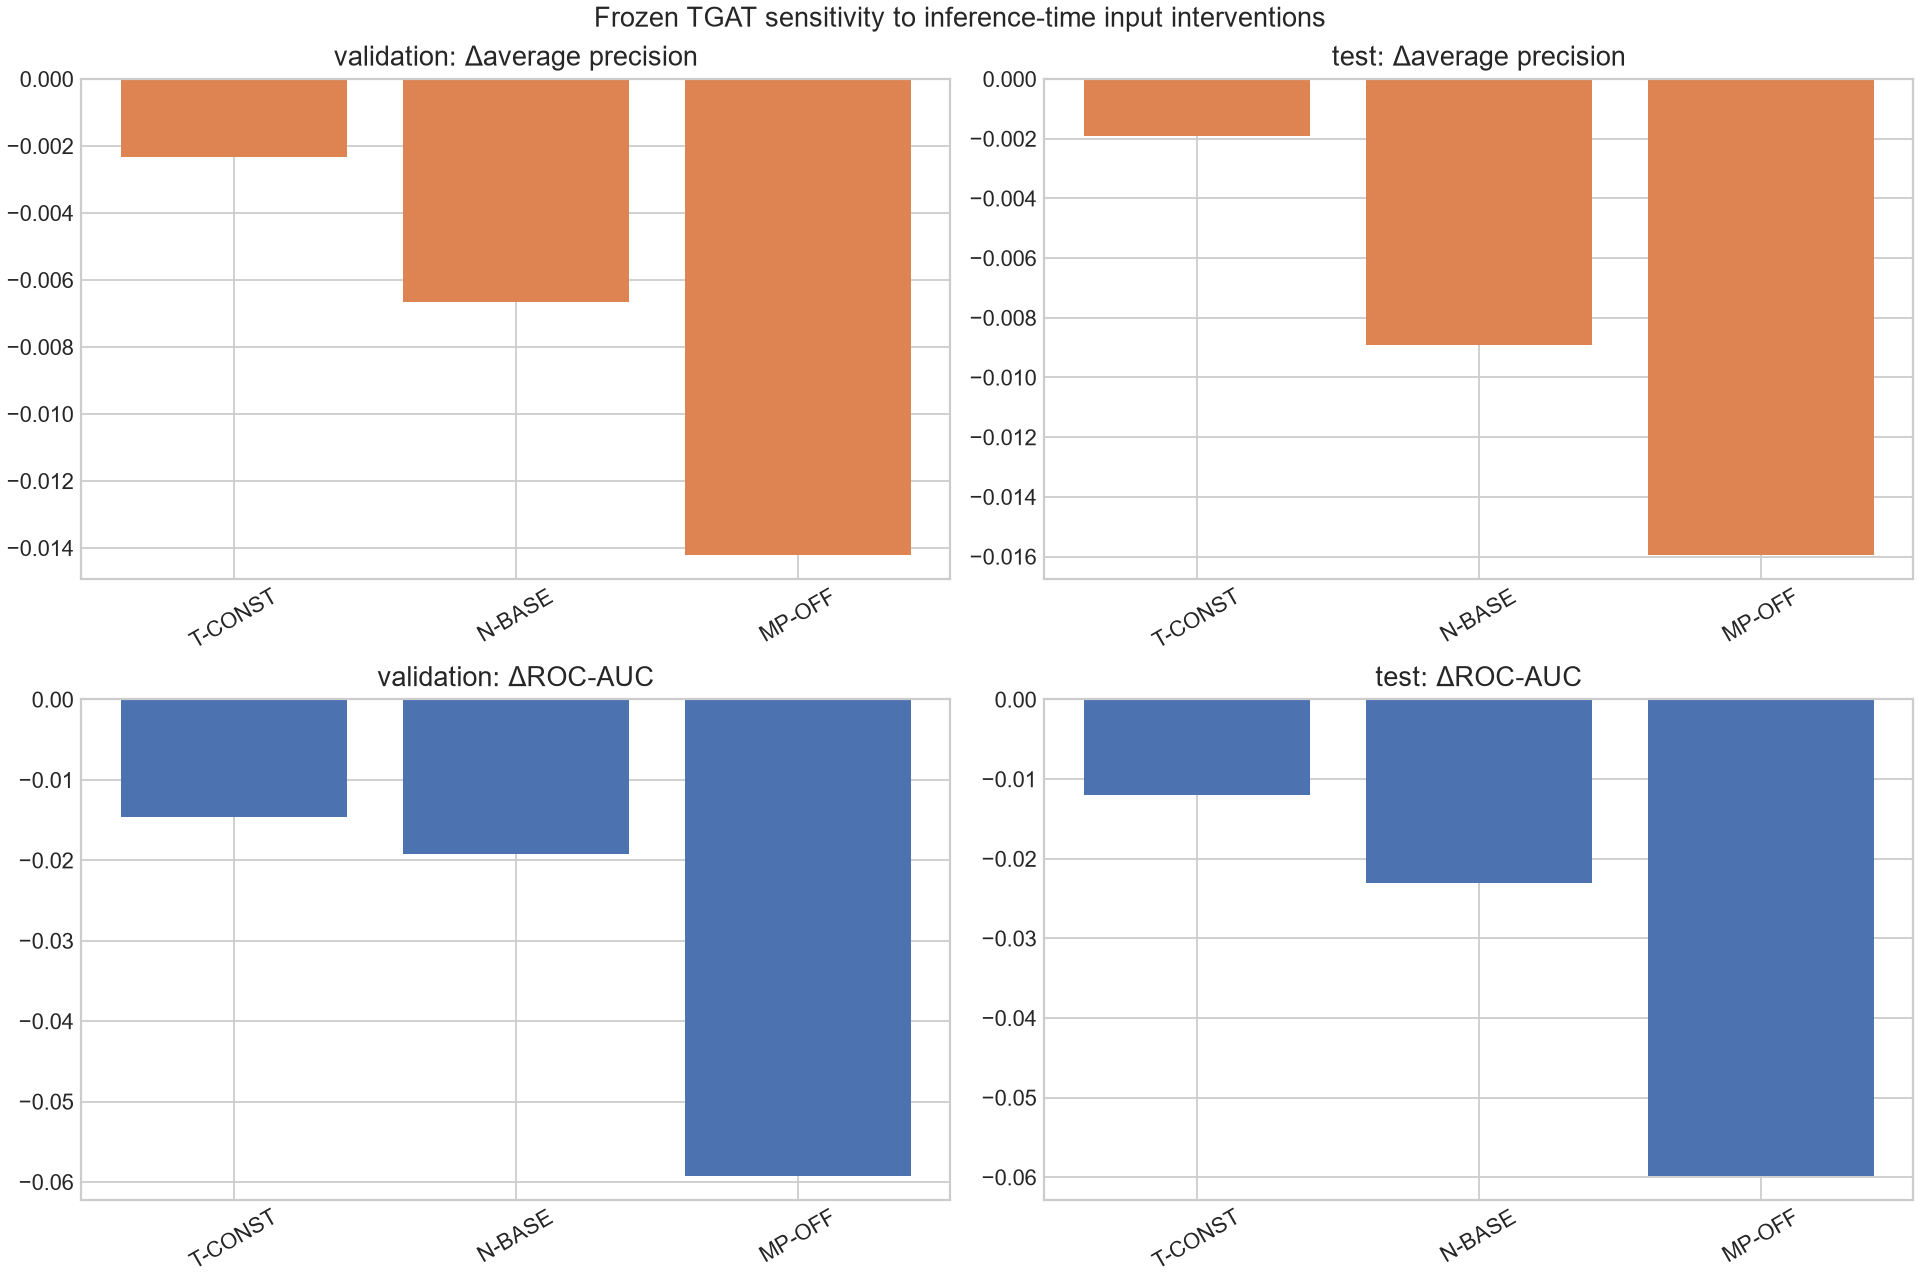

,target_node_id,base_logit,target_core_change_absolute_logit_delta,target_risk_change_absolute_logit_delta,neighbor_change_absolute_logit_delta,passed
0,1809844,0.123636,0.965901,0.00878,0.0,True


,Check,Passed
0,full_predictions_reproduced,True
1,all_variants_both_splits,True
2,all_outputs_finite,True
3,model_state_unchanged,True
4,mp_off_retains_target_root_and_risk_only,True


In [10]:
ablation_rows = pd.DataFrame(ablation['split_results'])
full_reference = ablation_rows[ablation_rows.variant.eq('FULL')][
    ['split', 'average_precision', 'roc_auc']
].rename(columns={'average_precision': 'full_ap', 'roc_auc': 'full_roc_auc'})
ablation_view = ablation_rows.merge(full_reference, on='split')
ablation_view['delta_ap'] = ablation_view['average_precision'] - ablation_view['full_ap']
ablation_view['delta_roc_auc'] = ablation_view['roc_auc'] - ablation_view['full_roc_auc']
display(ablation_view[[
    'split', 'variant', 'average_precision', 'delta_ap', 'roc_auc', 'delta_roc_auc',
]].style.format({
    'average_precision': '{:.4f}', 'delta_ap': '{:+.4f}',
    'roc_auc': '{:.4f}', 'delta_roc_auc': '{:+.4f}',
}))
display(Image(filename=str(ablation_runner.FIGURE_PATH), width=1050))

display(pd.DataFrame([ablation['mp_off_root_path_check']]))
display(pd.DataFrame(ablation['technical_gates'].items(), columns=['Check', 'Passed']))
assert all(ablation['technical_gates'].values())


## 11. Một số error case có effect lớn

Các panel chọn một FP và một FN có tổng absolute feature effect lớn trên mỗi split. Chúng dùng để đọc hành vi của model theo từng trường hợp, không đại diện cho toàn cohort và không phải bằng chứng fraud ring.


,split,cohort,node_id,direct_top5,gnnexplainer_top5,feature_spearman
0,validation,FP,1942636,"[F11, F06, F03, F04, F07]","[F11, F17, F09, F15, F05]",0.851360
1,validation,FN,675905,"[F03, F04, F07, F08, F11]","[F03, F07, F08, F10, F04]",0.778833
2,test,FP,2201167,"[F11, F06, F03, F04, F17]","[F11, F17, F15, F15-missing, F05]",0.078002
3,test,FN,841612,"[F03, F04, F11, F06, F07]","[F03, F07, F04, F06, F11]",0.603605


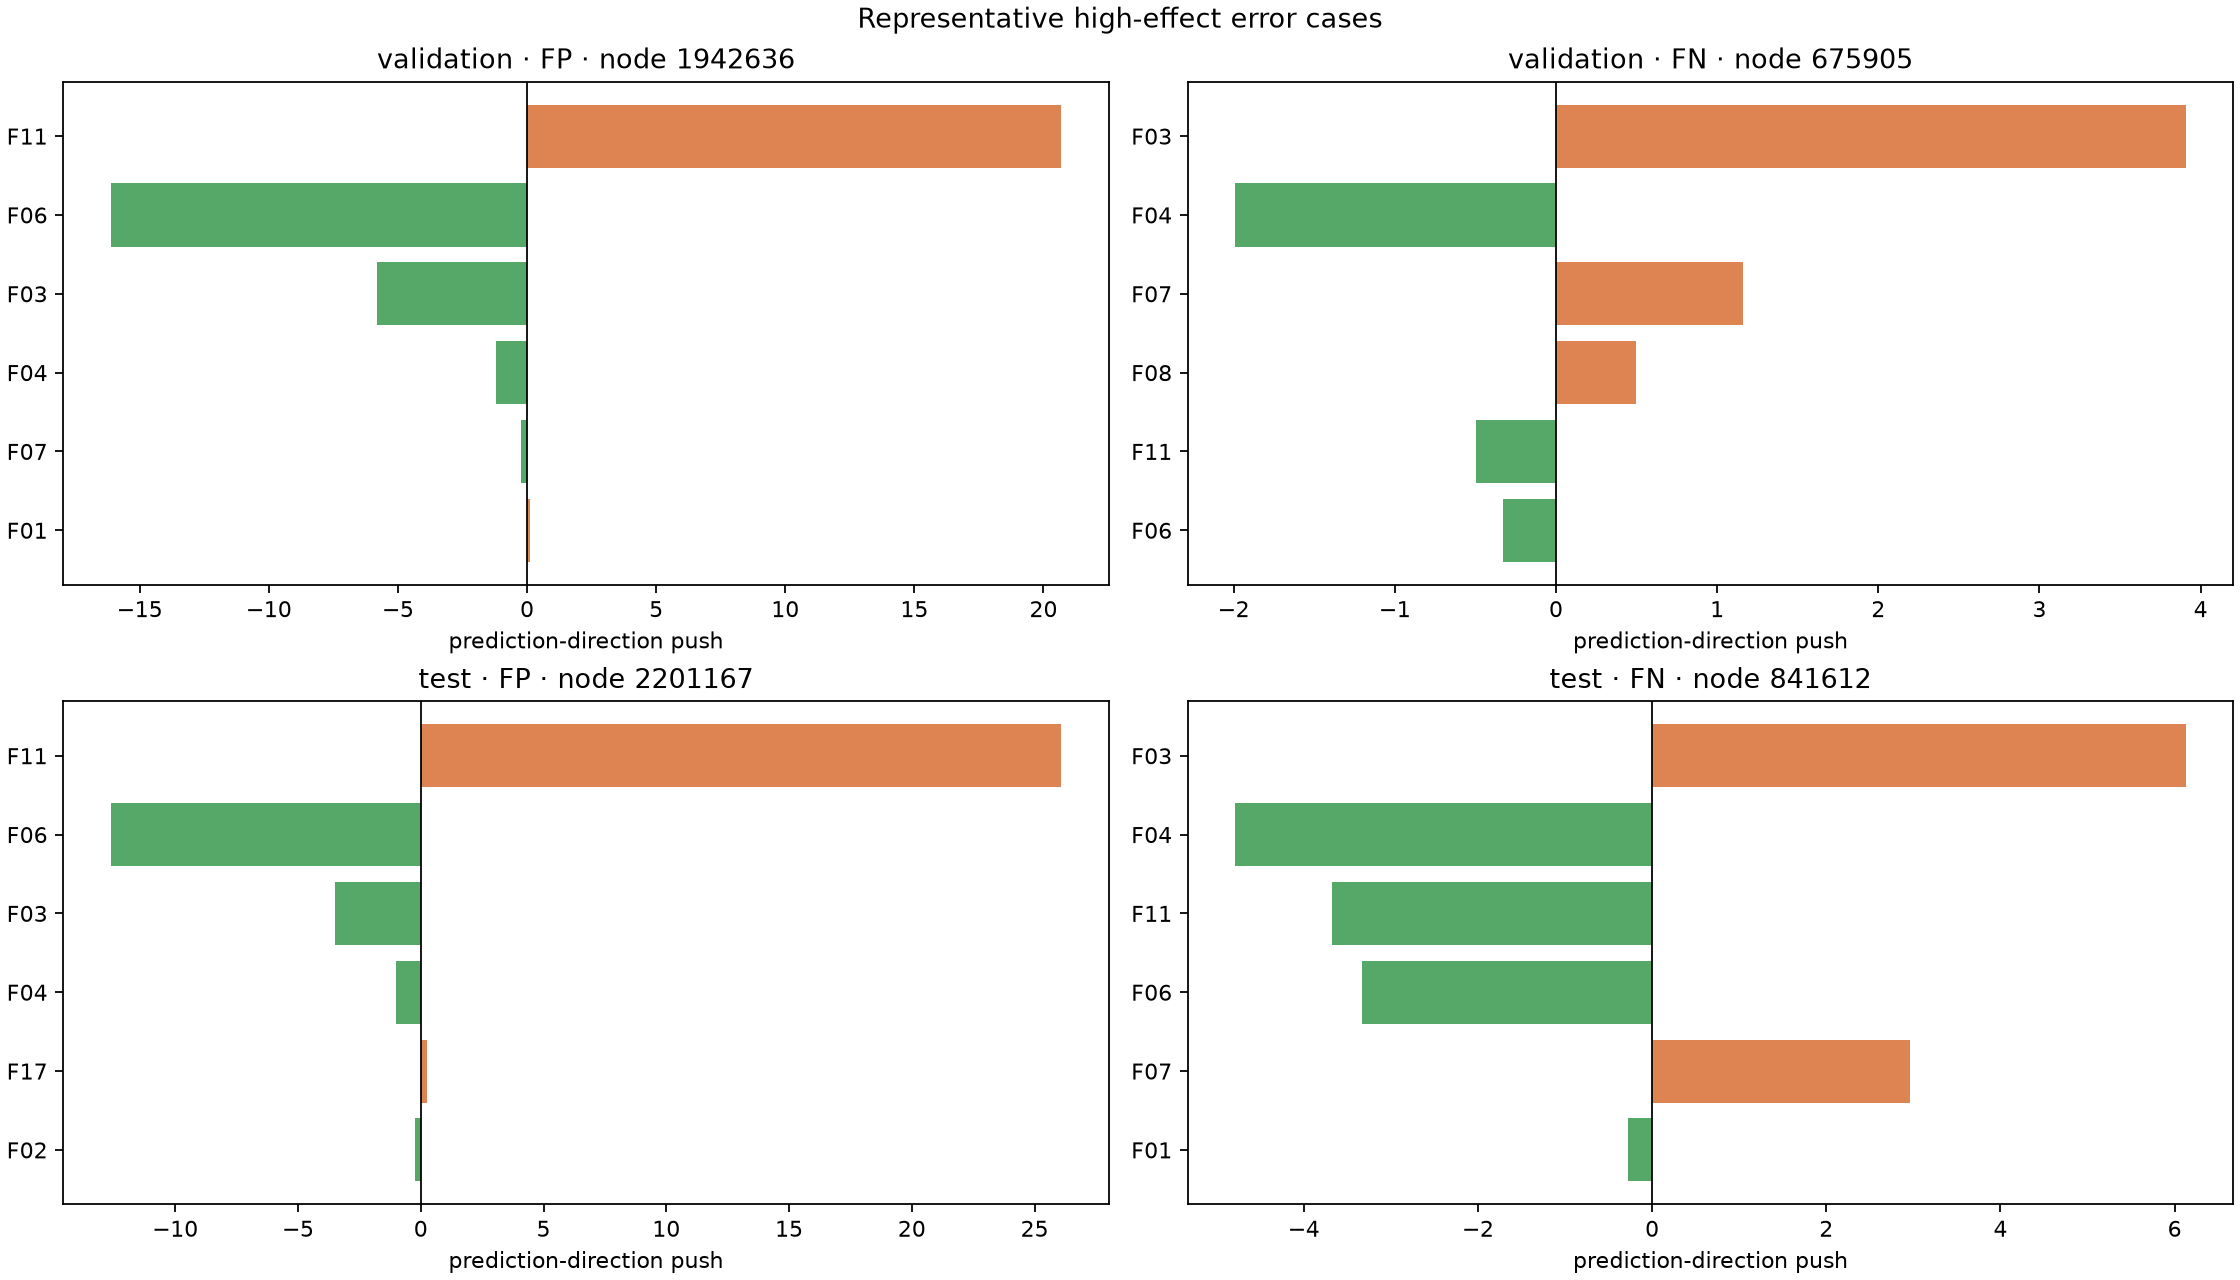

In [11]:
error_targets = [
    row for row in attribution['targets'] if row['cohort'] in {'FP', 'FN'}
]
case_rows = []
for split in ('validation', 'test'):
    for cohort in ('FP', 'FN'):
        candidates = [r for r in error_targets if r['split'] == split and r['cohort'] == cohort]
        chosen = max(candidates, key=lambda r: sum(r['feature_direct_absolute_effect']))
        case_rows.append({
            'split': split, 'cohort': cohort, 'node_id': chosen['node_id'],
            'direct_top5': chosen['direct_top5'],
            'gnnexplainer_top5': chosen['gnnexplainer_top5'],
            'feature_spearman': chosen['feature_spearman'],
        })
display(pd.DataFrame(case_rows))
display(Image(filename=str(attribution_runner.CASE_FIGURE), width=1100))


## 12. Kết luận

- Không có feature nào vừa hỗ trợ phía dự đoán sai, vừa hỗ trợ mạnh hơn control, rồi lặp lại kết quả đó trên cả validation và test. F16-missing chỉ đạt hai điều kiện ở FP trên test; community-risk chỉ đạt ở FN trên test.
- Community-risk có median effect nhỏ và đổi dấu theo cohort/split. Nó có thể hỗ trợ phía dự đoán của một số lỗi, nhưng không giải thích một mình toàn bộ FP/FN.
- T-CONST làm AP và ROC-AUC giảm trên cả hai split, cho thấy model sử dụng sự khác nhau về thời gian giữa các event.
- N-BASE làm cả hai metric giảm rõ hơn T-CONST; MP-OFF tạo mức giảm lớn nhất, với AP giảm khoảng 0,0142–0,0160 và ROC-AUC giảm khoảng 0,059 trên hai split. Unit check đồng thời xác nhận target core feature và community-risk vẫn thay đổi logit, còn thay neighbor không ảnh hưởng khi message passing đã tắt.

Các kết quả mô tả độ nhạy và cơ chế dự đoán của frozen TGAT trong bài toán full-history transductive node classification. Chúng không chứng minh đầu vào gây ra fraud hoặc gây ra lỗi trong thế giới thực.
